In [2]:
%cd ..

c:\Users\almei\Documents\GitHub\research_ner_leaderboard


In [ ]:
import torch
import numpy as np
from transformers import AutoTokenizer
from transformers import AutoModelForTokenClassification, Trainer, TrainingArguments

from spesia_ner.metrics import compute_metrics
from spesia_ner.datasets import ClinicalRecordsDataset, DataCollatorForMultiLabelTokenClassification
from spesia_ner.trainers import MultiLabelTokenTrainer

model_id = "jhu-clsp/mmBERT-base"
tags_to_consider = [
    # 'Abbreviation',
    # 'Negation',
    # 'Therapeutic or Preventive Procedure',
    # 'Health Care Activity',
    # 'Diagnostic Procedure',
    # 'Clinical Attribute',
    # 'Laboratory or Test Result',
    # 'Health Care Related Organization',
    # 'Professional or Occupational Group',
    # 'Patient or Disabled Group',
    # 'Sign or Symptom',
    # 'Injury or Poisoning',
    # 'Finding',
    # 'Disease or Syndrome',
    # 'Medical Device',
    # 'Drug Delivery Device',
    # 'Temporal Concept',
    # 'Pharmacologic Substance',
    # 'Organic Chemical',
    # 'Body Part, Organ, or Organ Component',
    # 'Body Location or Region',
    ]

semantic_groups_to_consider = [
    # 'Activities & Behaviors',
    'Anatomy',
    'Chemicals & Drugs',
    'Concepts & Ideas',
    'Devices',
    'Disorders',
    # 'Genes & Molecular Sequences',
    # 'Geographic Areas',
    'Living Beings',
    # 'Objects',
    # 'Occupations',
    'Organizations',
    'Phenomena',
    'Physiology',
    'Procedures'
]

tokenizer = AutoTokenizer.from_pretrained(model_id, use_fast=True)

train_dataset = ClinicalRecordsDataset(
    'data/SemClinBr/annotated_records', 
    tokenizer, 
    semantic_groups_to_consider=semantic_groups_to_consider,
    label_type='semantic_groups', 
    split="train")

val_dataset = ClinicalRecordsDataset(
    'data/SemClinBr/annotated_records', 
    tokenizer, 
    semantic_groups_to_consider=semantic_groups_to_consider,
    label_type='semantic_groups', 
    split="val")

test_dataset = ClinicalRecordsDataset(
    'data/SemClinBr/annotated_records', 
    tokenizer, 
    semantic_groups_to_consider=semantic_groups_to_consider,
    label_type='semantic_groups', 
    split="test")

model = AutoModelForTokenClassification.from_pretrained(model_id, num_labels=train_dataset.num_labels)

Loading all Records: 100%|██████████| 1000/1000 [00:05<00:00, 194.02it/s]


Total de registros carregados: 1000


Mapping tags to UMLS semantic groups: 100%|██████████| 1000/1000 [00:00<00:00, 53656.87it/s]


Ignored labels due to low sample count: ['Genes & Molecular Sequences', 'Geographic Areas', 'Occupations']


Loading all Records: 100%|██████████| 1000/1000 [00:00<00:00, 1506.18it/s]


...

Total de registros carregados: 1000


Mapping tags to UMLS semantic groups: 100%|██████████| 1000/1000 [00:00<00:00, 31615.52it/s]


Ignored labels due to low sample count: ['Genes & Molecular Sequences', 'Geographic Areas', 'Occupations']


Some weights of ModernBertForTokenClassification were not initialized from the model checkpoint at jhu-clsp/mmBERT-base and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Xet Storage is enabled for this repo, but the 'hf_xet' package is not installed. Falling back to regular HTTP download. For better performance, install the package with: `pip install huggingface_hub[hf_xet]` or `pip install hf_xet`
Exception ignored in: <function tqdm.__del__ at 0x0000029738E98180>
Traceback (most recent call last):
  File "c:\Users\almei\Documents\GitHub\research_ner_leaderboard\.venv\Lib\site-packages\tqdm\std.py", line 1148, in __del__
    self.close()
  File "c:\Users\almei\Documents\GitHub\research_ner_leaderboard\.venv\Lib\site-packages\tqdm\notebook.py", line 279, in close
    self.disp(bar_style='danger', check_delay=False)
    ^^^^^^^^^
AttributeError: 'tqdm' object has no attribute 'disp'


In [ ]:
from spesia_ner.trainers import EarlyStoppingCallback


training_args = TrainingArguments(
    output_dir="./output",
    per_device_train_batch_size=10,
    gradient_accumulation_steps=5,
    num_train_epochs=40,
    learning_rate=5e-5,
    include_for_metrics=['inputs'],
    eval_strategy="epoch",
    logging_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="eval_loss"
)

data_collator = DataCollatorForMultiLabelTokenClassification(
    pad_token_id=tokenizer.pad_token_id,
    max_length=512,
    num_labels=train_dataset.num_labels
)

trainer = MultiLabelTokenTrainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    processing_class=tokenizer,
    data_collator=data_collator,
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(patience=5)],
    pos_weight=train_dataset.pos_weight
)

trainer.train()

Epoch,Training Loss,Validation Loss,Best Threshold,Macro Precision,Macro Recall,Macro F1,Macro Auc,Micro Precision,Micro Recall,Micro F1,Micro Auc
1,2.953000,1.756462,0.220000,0.181650,0.248656,0.188403,0.666855,0.224555,0.471425,0.304206,0.821884
2,1.693400,1.343550,0.290000,0.503436,0.430483,0.445438,0.837859,0.538018,0.565815,0.551566,0.898076
3,1.370200,1.153391,0.340000,0.553012,0.581329,0.543024,0.914618,0.565096,0.709439,0.629094,0.944313
4,1.147000,1.018389,0.360000,0.607149,0.648537,0.613693,0.937141,0.640314,0.724599,0.679854,0.958803
5,0.973000,0.924041,0.360000,0.646417,0.693488,0.665885,0.949791,0.687857,0.747823,0.716588,0.964436
6,0.827100,0.909388,0.370000,0.658422,0.718218,0.681044,0.950655,0.690236,0.762836,0.724722,0.964028
7,0.709500,0.937223,0.390000,0.687081,0.703553,0.692775,0.947132,0.709546,0.768261,0.737737,0.963232
8,0.625100,0.940536,0.370000,0.666584,0.727205,0.692372,0.949141,0.701117,0.775210,0.736304,0.963585
9,0.532100,1.019500,0.500000,0.694778,0.686382,0.686625,0.948457,0.730647,0.722634,0.726619,0.957872
10,0.451400,1.052568,0.440000,0.705163,0.685411,0.692256,0.941724,0.718038,0.751811,0.734537,0.958739


TrainOutput(global_step=144, training_loss=0.9985448602173064, metrics={'train_runtime': 212.7879, 'train_samples_per_second': 112.224, 'train_steps_per_second': 2.256, 'total_flos': 2441324600893440.0, 'train_loss': 0.9985448602173064, 'epoch': 12.0})

In [4]:
trainer.eval_dataset = test_dataset
trainer.evaluate()

{'eval_loss': 0.8378369212150574,
 'eval_best_threshold': 0.42000000000000004,
 'eval_macro_precision': 0.7294879149235053,
 'eval_macro_recall': 0.7223375361692491,
 'eval_macro_f1': 0.7234746819770915,
 'eval_macro_auc': 0.9555904128091738,
 'eval_micro_precision': 0.7688216155043146,
 'eval_micro_recall': 0.775447307593528,
 'eval_micro_f1': 0.7721202477695062,
 'eval_micro_auc': 0.9709728943525966,
 'eval_runtime': 5.2128,
 'eval_samples_per_second': 39.134,
 'eval_steps_per_second': 4.988,
 'epoch': 13.0}

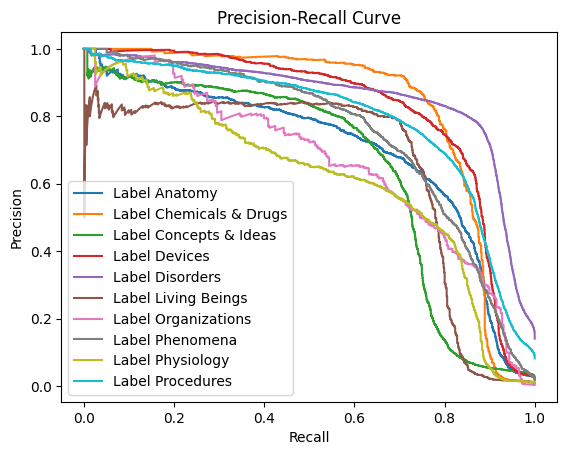

In [5]:
import matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_curve

# Get predictions object
pred_output = trainer.predict(test_dataset)

# Get probabilities (sigmoid for multilabel)
probs = 1 / (1 + np.exp(-pred_output.predictions))
labels = pred_output.label_ids.astype(int)

# For single-label: flatten arrays
if probs.shape[-1] == 1:
    probs_flat = probs.reshape(-1)
    labels_flat = labels.reshape(-1)
else:
    # For multilabel: plot for each label
    probs_flat = probs.reshape(-1, probs.shape[-1])
    labels_flat = labels.reshape(-1, labels.shape[-1])

# Plot for each label (or just one if single-label)
for i in range(probs_flat.shape[-1] if probs_flat.ndim > 1 else 1):
    if probs_flat.ndim > 1:
        y_score = probs_flat[:, i]
        y_true = labels_flat[:, i]
        label_name = f"Label {semantic_groups_to_consider[i]}"
    else:
        y_score = probs_flat
        y_true = labels_flat
        label_name = "Label"

    precision, recall, thresholds = precision_recall_curve(y_true, y_score)
    plt.plot(recall, precision, label=label_name)

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.legend()
plt.show()

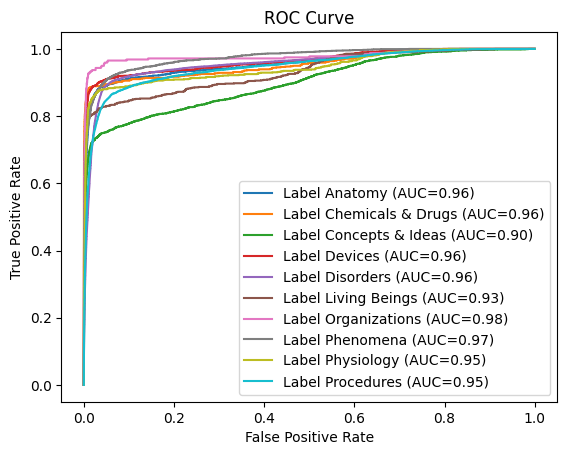

In [6]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, roc_auc_score

# Get predictions object
pred_output = trainer.predict(test_dataset)

# Get probabilities (sigmoid for multilabel)
probs = 1 / (1 + np.exp(-pred_output.predictions))
labels = pred_output.label_ids.astype(int)

# For single-label: flatten arrays
if probs.shape[-1] == 1:
    probs_flat = probs.reshape(-1)
    labels_flat = labels.reshape(-1)
else:
    # For multilabel: plot for each label
    probs_flat = probs.reshape(-1, probs.shape[-1])
    labels_flat = labels.reshape(-1, labels.shape[-1])

# Plot ROC curve for each label (or just one if single-label)
for i in range(probs_flat.shape[-1] if probs_flat.ndim > 1 else 1):
    if probs_flat.ndim > 1:
        y_score = probs_flat[:, i]
        y_true = labels_flat[:, i]
        label_name = f"Label {semantic_groups_to_consider[i]}"
    else:
        y_score = probs_flat
        y_true = labels_flat
        label_name = "Label"

    fpr, tpr, thresholds = roc_curve(y_true, y_score)
    auc = roc_auc_score(y_true, y_score)
    plt.plot(fpr, tpr, label=f"{label_name} (AUC={auc:.2f})")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()